# L1 · Notebook 02 — CartPole：连续状态 MDP

**对应 PPT**：`L1-basic.tex` §连续 vs 离散 MDP

## 教学目标

1. 见识"真实环境"：连续状态空间（4 维实数向量）+ 离散动作（2 个）
2. 用 `gymnasium` 标准 API：`reset` / `step` / `action_space` / `observation_space`
3. 用随机策略当基线，理解"什么是 hard 任务"
4. 铺垫 L8 价值函数逼近：连续状态怎么用神经网络处理

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from shared.plotting import setup_chinese_font

setup_chinese_font()
print('gymnasium', gym.__version__)

gymnasium 0.27.1


## 1. 创建环境，看 MDP 五元组

CartPole-v1：
- 状态 $s\in\mathbb{R}^4$ = (cart position, cart velocity, pole angle, pole angular velocity)
- 动作 $a\in\{0, 1\}$ = (向左推, 向右推)
- 奖励：每存活 1 步得 +1
- 终止：杆倒下（|angle| > 12°）或小车出界（|x| > 2.4），或步数超过 500

In [3]:
env = gym.make('CartPole-v1')
print('observation_space:', env.observation_space)
print('  low :', env.observation_space.low)
print('  high:', env.observation_space.high)
print()
print('action_space:', env.action_space)
print()
print('每步奖励 = +1 直到失败；最大步数 = env.spec.max_episode_steps =', env.spec.max_episode_steps)

observation_space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
  low : [-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38]
  high: [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38]

action_space: Discrete(2)

每步奖励 = +1 直到失败；最大步数 = env.spec.max_episode_steps = 500


**对比 GridWorld**：

| | GridWorld | CartPole |
|---|---|---|
| 状态 | 25 个离散网格 | 连续 $\mathbb{R}^4$ |
| 动作 | 5 个离散 | 2 个离散 |
| 转移 | 确定性 | 物理仿真（确定性，但因状态连续，不可能 tabular） |
| 奖励 | 4 种取值 | 每步 +1 直到失败 |

→ 连续状态意味着我们 **无法把 v(s) 存进表格**。L7+ 价值函数逼近就是为了解决这个问题。

## 2. 单条轨迹：随机策略

In [4]:
obs, info = env.reset(seed=0)
print(f'初始状态 s_0 = {obs}')
print(f'(cart_x={obs[0]:+.4f}, cart_v={obs[1]:+.4f}, angle={obs[2]:+.4f} rad, ang_v={obs[3]:+.4f})')
print()

states, actions, rewards = [obs], [], []
done = False
rng = np.random.default_rng(0)
while not done:
    a = int(rng.integers(0, 2))  # 0 or 1
    obs, r, terminated, truncated, info = env.step(a)
    states.append(obs); actions.append(a); rewards.append(r)
    done = terminated or truncated

print(f'轨迹长度 T = {len(actions)}')
print(f'累积奖励 G_0 = {sum(rewards):.0f}  (= 存活步数)')
print(f'终止状态 s_T = {states[-1]}')
print(f'失败原因: |angle|={abs(states[-1][2]):.4f} rad ({np.degrees(abs(states[-1][2])):.1f}°), |x|={abs(states[-1][0]):.4f}')
env.close()

初始状态 s_0 = [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]
(cart_x=+0.0137, cart_v=-0.0230, angle=-0.0459 rad, ang_v=-0.0483)

轨迹长度 T = 18
累积奖励 G_0 = 18  (= 存活步数)
终止状态 s_T = [ 0.0674871   1.1702203  -0.23051922 -2.351691  ]
失败原因: |angle|=0.2305 rad (13.2°), |x|=0.0675


## 3. 状态轨迹可视化

看 4 维状态随时间演化，理解为什么"杆会倒"。

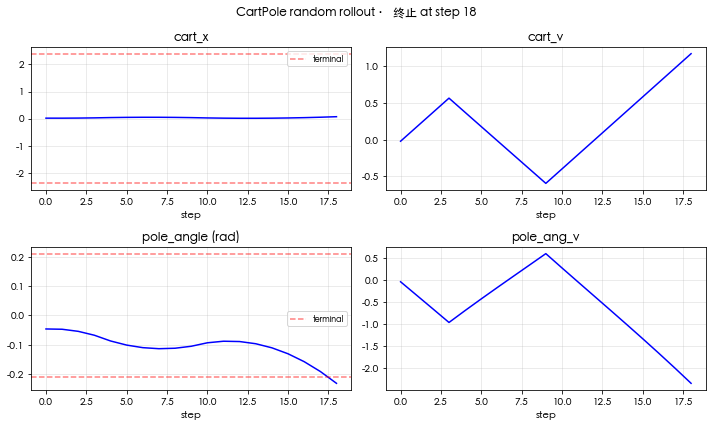

In [4]:
states_arr = np.array(states)
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
labels = ['cart_x', 'cart_v', 'pole_angle (rad)', 'pole_ang_v']
limits = [(-2.4, 2.4), None, (-0.21, 0.21), None]  # ±12° = ±0.209 rad
for i, ax in enumerate(axes.flat):
    ax.plot(states_arr[:, i], 'b-', linewidth=1.5)
    ax.set_title(labels[i])
    ax.set_xlabel('step')
    ax.grid(True, alpha=0.3)
    if limits[i] is not None:
        ax.axhline(limits[i][0], color='red', linestyle='--', alpha=0.5, label='terminal')
        ax.axhline(limits[i][1], color='red', linestyle='--', alpha=0.5)
        ax.legend(fontsize=8)
fig.suptitle(f'CartPole random rollout · 终止 at step {len(actions)}')
plt.tight_layout()
plt.savefig('figures/cartpole_random_rollout.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. 随机策略基线：100 episode 平均存活步数

In [5]:
env = gym.make('CartPole-v1')
n_episodes = 100
lengths = []
rng = np.random.default_rng(42)
for ep in range(n_episodes):
    obs, _ = env.reset(seed=int(rng.integers(0, 1_000_000)))
    done, T = False, 0
    while not done:
        a = int(rng.integers(0, 2))
        obs, r, term, trunc, _ = env.step(a)
        T += 1
        done = term or trunc
    lengths.append(T)
env.close()

lengths = np.array(lengths)
print(f'random policy ({n_episodes} episodes):')
print(f'  mean   = {lengths.mean():.2f} steps')
print(f'  median = {np.median(lengths):.0f}')
print(f'  std    = {lengths.std():.2f}')
print(f'  min/max = {lengths.min()}/{lengths.max()}')
print(f'\n参考：CartPole-v1 视为"已解决"需要平均 ≥ 475 步')

random policy (100 episodes):
  mean   = 22.33 steps
  median = 20
  std    = 11.17
  min/max = 10/62

参考：CartPole-v1 视为"已解决"需要平均 ≥ 475 步


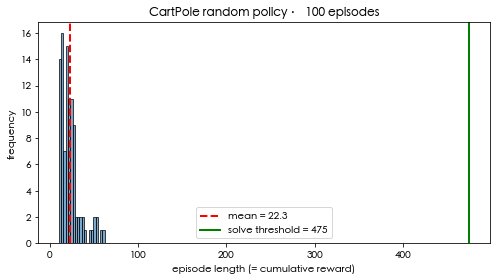

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lengths, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(lengths.mean(), color='red', linestyle='--', linewidth=2, label=f'mean = {lengths.mean():.1f}')
ax.axvline(475, color='green', linestyle='-', linewidth=2, label='solve threshold = 475')
ax.set_xlabel('episode length (= cumulative reward)')
ax.set_ylabel('frequency')
ax.set_title(f'CartPole random policy · {n_episodes} episodes')
ax.legend()
plt.tight_layout()
plt.savefig('figures/cartpole_random_lengths.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. 课堂诊断小结

| 论断 | 数值 |
|---|---|
| 状态空间维度 | $\mathbb{R}^4$ — 不可表格化 |
| 随机策略平均存活 | ~22 步 |
| 解决阈值 | 475 步（22× 提升） |
| → 显然需要学习 | L8 DQN 在 CartPole 上能稳定到 500 |

## 思考题

1. 如果把 4 维状态每维离散成 10 格，状态总数 = $10^4$。直接 tabular 可行吗？（提示：可以但浪费——大多数格子从未访问）
2. 物理上，最难学的状态维度是哪个？(提示：角速度 vs 位置)
3. 如果奖励改成"|angle| 越小奖励越大"，会变好学还是难学？(reward shaping 引导)